# Домашнее задание 3. Градиентный спуск, Ньютон, BFGS: реализация и сравнение

**Выдано:** 7 октября 2026. **Срок сдачи:** 21 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw03/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 4 ([конспект](../lectures/lecture04/lecture04.md)) и лекция 5 ([конспект](../lectures/lecture05/lecture05.md), [демо](../lectures/lecture05/demo05.ipynb), [семинар](../lectures/lecture05/seminar05.ipynb)). Ничего сверх лекций не требуется. Ориентировочное время — 3–4 часа.

**Устройство задания.** Обвязка — функции Розенброка, цепь, данные синуса, рисовальщики — дана готовой в ячейке ниже; вы пишете только то, что составляет метод: направление, выбор длины шага, обновление матрицы, шаг Гаусса–Ньютона. Под каждым заданием стоит проверка (`assert`), которая ловит смысл: если она прошла, можно идти дальше. Все методы работают с одними и теми же параметрами, чтобы числа совпали с конспектом: backtracking по Армихо с $c=10^{-4}$ от $\alpha=1$ делением пополам, останов по $\lVert\nabla f\rVert\le10^{-6}$ (у Ньютона — $10^{-10}$).

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`; в Colab ничего ставить не нужно.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, least_squares

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

BLUE, ORANGE, AQUA, RED, VIOLET, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#4a3aa7", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})


# ---------------------------------------------------------------- задачи (даны готовыми)
def rosen(x):
    return (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2


def rosen_grad(x):
    return np.array([-2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0] ** 2), 200 * (x[1] - x[0] ** 2)])


def rosen_hess(x):
    return np.array([[2 - 400 * x[1] + 1200 * x[0] ** 2, -400 * x[0]], [-400 * x[0], 200.0]])


X0_ROSEN = np.array([-1.2, 1.0])


def make_chain(N, D=70.0, g=9.81):
    """Цепь без пола (лекция 1, §7.3; лекция 4): E(v) = 1/2 v^T H v + b^T v + const.
    Возвращает (energy, grad_E, H, b, v0): функция, градиент, гессиан, линейный член, старт (прямая между концами)."""
    m = 4.0 / N
    K = 2 * np.eye(N) - np.eye(N, k=1) - np.eye(N, k=-1)
    H = np.kron(np.eye(2), D * K)
    b = np.zeros(2 * N)
    b[0] -= D * (-2.0); b[N - 1] -= D * 2.0; b[N] -= D * 1.0; b[2 * N - 1] -= D * 1.0; b[N:] += m * g
    v0 = np.r_[np.linspace(-2, 2, N + 2)[1:-1], np.ones(N)]

    def energy(v):
        y, z = np.r_[-2.0, v[:N], 2.0], np.r_[1.0, v[N:], 1.0]
        return 0.5 * D * np.sum(np.diff(y) ** 2 + np.diff(z) ** 2) + m * g * np.sum(z[1:-1])

    return energy, (lambda v: H @ v + b), H, b, v0


# данные задачи 2(б) ДЗ 2: y = 2 sin(3t + 0.7) + шум, 60 точек, те же 20 стартов
data_rng = np.random.default_rng(2026)
t_data = np.sort(data_rng.uniform(0, 2 * np.pi, 60))
y_data = 2.0 * np.sin(3.0 * t_data + 0.7) + 0.2 * data_rng.standard_normal(60)
starts = data_rng.uniform(-5, 5, (20, 3))
X0_SINE = np.array([1.0, 3.0, 0.0])


def sine_resid(x):
    """Невязки модели x1 sin(x2 t + x3) на данных."""
    return x[0] * np.sin(x[1] * t_data + x[2]) - y_data


def sine_jac(x):
    """Якобиан невязок (60 x 3): столбцы — производные по амплитуде, частоте, фазе."""
    s, c = np.sin(x[1] * t_data + x[2]), np.cos(x[1] * t_data + x[2])
    return np.c_[s, x[0] * t_data * c, x[0] * c]


def sine_f(x):
    r = sine_resid(x); return 0.5 * (r @ r)


def sine_grad(x):
    return sine_jac(x).T @ sine_resid(x)


# ---------------------------------------------------------------- рисовальщики (принимают ax=None, возвращают ax)
def plot_rosen_path(paths, labels=None, ax=None, xlim=(-2.2, 2.2), ylim=(-3.5, 3.2), every=50):
    """Линии уровня Розенброка и пути методов; длинные пути прореживаются (каждая every-я точка после 30-й)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    X, Y = np.meshgrid(np.linspace(*xlim, 400), np.linspace(*ylim, 400))
    ax.contour(X, Y, (1 - X) ** 2 + 100 * (Y - X ** 2) ** 2, levels=np.logspace(-1, 3.3, 14), colors=[GRAY], linewidths=0.7)
    colors = [BLUE, ORANGE, AQUA, VIOLET, RED]
    for i, p in enumerate(paths):
        pp = p if len(p) <= 60 else np.r_[p[:30], p[30::every]]
        ax.plot(pp[:, 0], pp[:, 1], "-o", ms=3 if len(p) > 60 else 4.5, lw=1.3, color=colors[i % 5], label=None if labels is None else labels[i])
    ax.plot(1, 1, "*", ms=13, color=RED, mec="white", zorder=7)
    ax.set(xlim=xlim, ylim=ylim, xlabel="$x_1$", ylabel="$x_2$"); ax.grid(False)
    if labels is not None:
        ax.legend(loc="upper left", fontsize=8)
    return ax


def plot_grad_norms(gnorms, labels=None, ax=None):
    """log10 нормы градиента по итерациям для нескольких методов (ось итераций логарифмическая)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 4.2))
    colors = [BLUE, ORANGE, AQUA, VIOLET, RED]
    for i, gn in enumerate(gnorms):
        ax.plot(np.arange(1, len(gn) + 1), np.log10(np.asarray(gn) + 1e-17), "-o" if len(gn) < 60 else "-", ms=3.5, lw=1.4, color=colors[i % 5], label=None if labels is None else labels[i])
    ax.set_xscale("log"); ax.set(xlabel="итерация $k$ (лог. шкала)", ylabel="$\\log_{10}\\Vert\\nabla f(x_k)\\Vert$")
    if labels is not None:
        ax.legend(fontsize=8)
    return ax


print("данные синуса:", t_data.shape, " стартов ДЗ 2:", len(starts), " f в старте (1, 3, 0):", round(sine_f(X0_SINE), 3))

данные синуса: (60,)  стартов ДЗ 2: 20  f в старте (1, 3, 0): 33.867


## Задача 1. Теория (4 балла)

По 1 баллу за пункт. Нужны выкладки, а не только ответ; численная проверка приветствуется, но текстом объясните, почему так.

**(а) Один шаг Ньютона.** $f(x)=x_1^2+2x_2^2+x_1x_2-4x_1-7x_2$. Из точки $x_0=(0,0)$ сделайте один шаг Ньютона руками: выпишите $\nabla f(x_0)$, $\nabla^2f$, решите систему $Hp=-g$ и проверьте, что в новой точке $\nabla f=0$. Почему здесь хватило одной итерации и какое свойство функции за это отвечает?

**(б) Цифры удваиваются.** Метод Ньютона для $F(x)=x^2-a$ даёт $x_{k+1}=\tfrac12(x_k+a/x_k)$. Покажите, что ошибка $e_k=x_k-\sqrt a$ удовлетворяет $e_{k+1}=\dfrac{e_k^2}{2x_k}$. Для $a=3$, $x_0=2$ выпишите $x_1,x_2,x_3$ и ошибки; сколько верных цифр прибавляет каждый шаг?

**(в) Секущее уравнение для $B$.** Обновление BFGS для самого гессиана (не обратного): $B_{k+1}=B_k-\dfrac{B_ks_ks_k^\top B_k}{s_k^\top B_ks_k}+\dfrac{y_ky_k^\top}{y_k^\top s_k}$. Проверьте подстановкой, что $B_{k+1}s_k=y_k$. Почему для этого нужно $y_k^\top s_k\ne0$, и что это условие означает для функции?

**(г) Что отбрасывает Гаусс–Ньютон.** $f(x)=\tfrac12\lVert r(x)\rVert^2$, $r(x)=\big(x_1-2,\ x_2-1,\ x_1x_2-1\big)$. Выпишите $J$, $J^\top J$ и полный гессиан $\nabla^2f=J^\top J+\sum_ir_i\nabla^2r_i$. Где отброшенный член равен нулю? Есть ли у этой задачи точка, где все невязки нулевые, и что это значит для сходимости Гаусса–Ньютона рядом с ней?

**(а)**

Градиент в точке $x_0=(0,0)$:

$$
\nabla f(x) = \begin{pmatrix} 2x_1 + x_2 - 4 \\ x_1 + 4x_2 - 7 \end{pmatrix},
\quad
g = \nabla f(x_0) = \begin{pmatrix} -4 \\ -7 \end{pmatrix}.
$$

Гессиан:

$$
H = \nabla^2f = \begin{pmatrix} 2 & 1 \\ 1 & 4 \end{pmatrix}.
$$

Решение системы $Hp = -g$:

$$
\begin{cases} 2p_1 + p_2 = 4, \\ p_1 + 4p_2 = 7, \end{cases}
\quad
\begin{cases} p_1 = \frac{9}{7}, \\ p_2 = \frac{10}{7}. \end{cases}
$$

Один шаг Ньютона:

$$
x_1 = x_0 + p = \left(\frac{9}{7}, \frac{10}{7}\right).
$$

Проверка градиента:

$$
\nabla f(x_1) = \begin{pmatrix} 2 * \frac{9}{7} + \frac{10}{7} - 4 \\ \frac{9}{7} + 4 * \frac{10}{7} - 7 \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}.
$$

Одной итерации хватило, поскольку функция квадратичная, а её Гессиан постоянен. Метод Ньютона точно находит стационарную точку квадратичной функции за один шаг. Так как $H$ положительно определен, эта точка является единственным глобальным минимумом.


**(б)**

**Ответ:**

Пользуясь $x_{k+1} = \frac{1}{2}\left(x_k + \frac{a}{x_k}\right)$ и $e_k = x_k - \sqrt{a}$, получается:

$$
e_{k+1} = x_{k+1} - \sqrt{a} = \frac{1}{2}\left(x_k + \frac{a}{x_k}\right) - \sqrt{a}
= \frac{x_k^2 + a - 2x_k\sqrt{a}}{2x_k} = \frac{(x_k - \sqrt{a})^2}{2x_k} = \frac{e_k^2}{2x_k}
$$

Для $a = 3$, $x_0 = 2$ (точное значение $\sqrt{3} \approx 1.732050808$):

$$
x_0 = 2,
\quad
e_0 \approx 0.267949192,
$$

$$
x_1 = \frac{1}{2}\left(2 + \frac{3}{2}\right) = 1.75,
\quad
e_1 \approx 0.017949192,
$$

$$
x_2 = \frac{1}{2}\left(1.75 + \frac{3}{1.75}\right) \approx 1.732142857,
\quad
e_2 \approx 9.2048 * 10^{-5},
$$

$$
x_3 = \frac{1}{2}\left(1.732142857 + \frac{3}{1.732142857}\right) \approx 1.732050810,
\quad
e_3 \approx 2.45 * 10^{-9}.
$$

Число верных десятичных цифр можно оценить как $-\log_{10}|e_k|$:

- $x_0$: около $0.57$ цифры;
- $x_1$: около $1.75$ цифры;
- $x_2$: около $4.04$ цифры;
- $x_3$: около $8.61$ цифры.

Каждый шаг примерно удваивает число верных цифр, поскольку ошибка квадратично зависит от предыдущей ошибки.

**(в)**

**Ответ:**

Проверка $B_{k+1} s_k = y_k$:

$$
B_{k+1} s_k = B_k s_k - \frac{B_k s_k s_k^\top B_k s_k}{s_k^\top B_k s_k} + \frac{y_k y_k^\top s_k}{y_k^\top s_k} = B_k s_k - B_k s_k + y_k = y_k.
$$

Условие $y_k^\top s_k \ne 0$ необходимо, чтобы знаменатель последнего слагаемого не был равен нулю. $y_k^\top s_k > 0$ означает положительную кривизну функции вдоль направления шага. Для строго выпуклой функции оно выполняется при $s_k \ne 0$. Это условие также позволяет сохранять положительную определённость матрицы $B$.


**(г)**

**Ответ:**

$$
r(x) = \begin{pmatrix} x_1 - 2 \\ x_2 - 1 \\ x_1 x_2 - 1 \end{pmatrix},
\quad
J = \frac{\partial r}{\partial x} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ x_2 & x_1 \end{pmatrix}.
$$

$$
J^\top J = \begin{pmatrix}
1 + x_2^2 & x_1 x_2 \\
x_1 x_2 & 1 + x_1^2
\end{pmatrix}.
$$

Полный гессиан:

$$
\nabla^2 f = J^\top J + \sum_i r_i \nabla^2 r_i.
$$

Первые две невязки линейны, поэтому их вторые производные равны нулю. Для третьей невязки $r_3 = x_1 x_2 - 1$:
$\nabla^2 r_3 = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}.$
Отсюда:

$$
\sum_i r_i \nabla^2 r_i = (x_1 x_2 - 1)\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix},
\quad
\nabla^2 f = \begin{pmatrix} 1 + x_2^2 & 2x_1 x_2 - 1 \\ 2x_1 x_2 - 1 & 1 + x_1^2 \end{pmatrix}.
$$

Отброшенный в методе Гаусса-Ньютона член равен нулю, когда $x_1 x_2 - 1 = 0$.

Все невязки одновременно равными нулю быть не могут: из $r_1 = 0$ и $r_2 = 0$ следует $x_1 = 2$, $x_2 = 1$, но тогда $r_3 = 2 \cdot 1 - 1 = 1 \ne 0$. Поэтому точного решения системы невязок нет. Вблизи точки, где невязки малы, отброшенный член также мал, и метод Гаусса — Ньютона может хорошо приближать метод Ньютона. Однако гарантии быстрой сходимости, характерной для случая нулевых невязок, здесь нет.


## Задача 2. Практика (6 баллов)

### (а) Три кирпича методов (2 балла)

Метод Ньютона с backtracking и BFGS собираются из трёх частей; каждую пишете отдельно, под каждой — проверка. Сигнатуры не меняйте: ниже готовые циклы `newton_damped` и `bfgs` используют именно их.

**TODO 1 — направление Ньютона.** `newton_direction(g, H)` возвращает $p$ — решение $Hp=-g$. Если $g^\top p\ge0$ (направление не спуск — гессиан индефинитен), верните вместо него решение системы с регуляризованной матрицей $H+(\lvert\lambda_{\min}\rvert+10^{-3})I$.

In [2]:
def newton_direction(g, H):
    """Направление Ньютона p = -H^{-1} g; при g^T p >= 0 — регуляризация H + (|lambda_min| + 1e-3) I."""
    p = np.linalg.solve(H, -g)
    if g @ p >= 0:
        lambda_min = np.min(np.linalg.eigvalsh(H))
        H_reg = H + (abs(lambda_min) + 1e-3) * np.eye(H.shape[0])
        p = np.linalg.solve(H_reg, -g)
    return p

In [3]:
# проверка TODO 1: на квадратичной из задачи 1(а) один шаг попадает в минимум; при индефинитном H направление — спуск
H_q = np.array([[2.0, 1.0], [1.0, 4.0]]); g_q = np.array([-4.0, -7.0])
assert np.allclose(newton_direction(g_q, H_q), [9 / 7, 10 / 7]), "на квадратичной 1(а) шаг Ньютона должен быть (9/7, 10/7): проверьте знак в решении системы"
H_ind = np.diag([1.0, -1.0]); g_ind = np.array([0.0, 1.0])
assert g_ind @ newton_direction(g_ind, H_ind) < 0, "при индефинитном H и g = (0, 1) чистый шаг (0, 1) идёт вверх — нужна регуляризация"
print("TODO 1: ok")

TODO 1: ok


**TODO 2 — длина шага по Армихо.** `armijo(f, x, p, g, c=1e-4)` возвращает $\alpha$: начинаем с $\alpha=1$ и делим пополам, пока не выполнено $f(x+\alpha p)\le f(x)+c\,\alpha\,g^\top p$ (лекция 4, §4.5; лекция 5, §3.4).

In [4]:
def armijo(f, x, p, g, c=1e-4):
    """Backtracking: alpha = 1, делим пополам до выполнения условия Армихо."""
    alpha = 1.0
    fx = f(x)
    while f(x + alpha * p) > fx + c * alpha * (g @ p):
        alpha *= 0.5
    return alpha

In [5]:
# проверка TODO 2: на f = 1/2 (x1^2 + 10 x2^2) из (3, 1) вдоль -g первый принятый шаг — ровно 1/8 (лекция 4, картинка 03)
Q2 = np.diag([1.0, 10.0]); f2 = lambda x: 0.5 * x @ Q2 @ x
x2 = np.array([3.0, 1.0]); g2 = Q2 @ x2
a = armijo(f2, x2, -g2, g2)
assert abs(a - 0.125) < 1e-12, f"ожидался шаг 1/8, получен {a}: делите пополам, начиная с 1, и проверяйте условие с c * alpha * g^T p"
assert armijo(f2, x2, -g2 * 1e-3, g2) == 1.0, "короткое направление должно приниматься целиком (alpha = 1)"
print("TODO 2: ok")

TODO 2: ok


**TODO 3 — обновление BFGS.** `bfgs_update(H, s, y)` возвращает $H_{k+1}=(I-\rho sy^\top)H(I-\rho ys^\top)+\rho ss^\top$, $\rho=1/(y^\top s)$ (лекция 5, §4.3).

In [6]:
def bfgs_update(H, s, y):
    """Обновление обратного гессиана BFGS по паре (s, y)."""
    rho = 1.0 / (y @ s)
    I = np.eye(H.shape[0])
    A = I - rho * np.outer(s, y)
    B = I - rho * np.outer(y, s)
    H_new = A @ H @ B + rho * np.outer(s, s)
    return H_new

In [7]:
# проверка TODO 3: секущее уравнение, симметрия, H > 0; на квадратичной kappa = 50 из (50, 1) с точным шагом два обновления дают H_2 = Q^{-1} (упражнение 11.5)
Hs = np.eye(3); s_, y_ = np.array([1.0, -2.0, 0.5]), np.array([0.5, -1.0, 2.0])
Hn = bfgs_update(Hs, s_, y_)
assert np.allclose(Hn @ y_, s_), "секущее уравнение H_{k+1} y = s нарушено: проверьте порядок s и y в формуле"
assert np.allclose(Hn, Hn.T) and np.all(np.linalg.eigvalsh(Hn) > 0), "H_{k+1} должна быть симметричной и положительно определённой при s^T y > 0"
Q50 = np.diag([1.0, 50.0]); xq = np.array([50.0, 1.0]); Hq = np.eye(2)
for _ in range(2):
    gq = Q50 @ xq; pq = -Hq @ gq; aq = -(gq @ pq) / (pq @ Q50 @ pq)      # точный шаг на квадратичной
    sq = aq * pq; xq = xq + sq; Hq = bfgs_update(Hq, sq, Q50 @ sq)
assert np.allclose(Hq, np.linalg.inv(Q50), atol=1e-10) and np.allclose(xq, 0, atol=1e-9), "после двух обновлений на квадратичной 2x2 должно получиться H_2 = Q^{-1} = diag(1, 0.02) и x_2 = 0"
print("TODO 3: ok;  H_2 =", Hq.round(6).tolist())

TODO 3: ok;  H_2 = [[1.0, 0.0], [0.0, 0.02]]


Сборка методов из кирпичей — дана готовой (сравните с лекцией: это ровно `newton_damped` и `bfgs` из `l5helpers.py`). `gd` — градиентный спуск с backtracking из лекции 4, тоже через ваш `armijo`.

In [8]:
def gd(f, grad, x0, alpha=None, tol=1e-6, maxit=100_000):
    """Градиентный спуск: alpha=None — backtracking по Армихо, иначе постоянный шаг. Возвращает (x, итераций, путь, нормы градиента)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]; gnorm = []
    for k in range(maxit):
        g = grad(x); gnorm.append(np.linalg.norm(g))
        if gnorm[-1] <= tol:
            return x, k, np.array(path), np.array(gnorm)
        a = armijo(f, x, -g, g) if alpha is None else alpha
        x = x - a * g; path.append(x.copy())
    return x, maxit, np.array(path), np.array(gnorm)


def newton_damped(f, grad, hess, x0, tol=1e-10, maxit=200):
    """Ньютон с backtracking. Возвращает (x, итераций, путь, нормы градиента)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]; gnorm = []
    for k in range(maxit):
        g = grad(x); gnorm.append(np.linalg.norm(g))
        if gnorm[-1] <= tol:
            return x, k, np.array(path), np.array(gnorm)
        p = newton_direction(g, hess(x))
        x = x + armijo(f, x, p, g) * p; path.append(x.copy())
    return x, maxit, np.array(path), np.array(gnorm)


def bfgs(f, grad, x0, tol=1e-6, maxit=10_000):
    """BFGS с H_0 = I и backtracking по Армихо. Возвращает (x, итераций, путь, нормы градиента)."""
    x = np.asarray(x0, float).copy(); H = np.eye(len(x)); g = grad(x); path = [x.copy()]; gnorm = [np.linalg.norm(g)]
    for k in range(maxit):
        if gnorm[-1] <= tol:
            return x, k, np.array(path), np.array(gnorm)
        p = -H @ g
        s = armijo(f, x, p, g) * p; x_new = x + s; g_new = grad(x_new); y = g_new - g
        if s @ y > 1e-12:                                   # условие кривизны, иначе H не трогаем
            H = bfgs_update(H, s, y)
        x, g = x_new, g_new; path.append(x.copy()); gnorm.append(np.linalg.norm(g))
    return x, maxit, np.array(path), np.array(gnorm)


print("методы собраны")

методы собраны


### (б) Розенброк и цепь: сравнение (2 балла)

1. Запустите три метода на Розенброке из $(-1.2,\,1)$ (спуск и BFGS — до $\lVert\nabla f\rVert\le10^{-6}$, Ньютон — до $10^{-10}$). Напечатайте таблицу: метод, число итераций, число вычислений $f$ (добавьте счётчик — например, обёрткой вокруг `rosen`), конечная точка. Ожидаемые числа конспекта — $13\,756$, $22$, $34$; расхождение до $5\,\%$ допустимо.
2. Нарисуйте две картинки готовыми рисовальщиками: пути трёх методов на линиях уровня (`plot_rosen_path`) и $\log_{10}\lVert\nabla f(x_k)\rVert$ по итерациям (`plot_grad_norms`). Назовите по графику тип сходимости каждого метода (лекция 4, §6; лекция 5, §3–4).
3. Цепь $N=40$: спуск с постоянным шагом $1/L$ ($L=\lambda_{\max}(H)$) против одного шага Ньютона `v0 - solve(H, grad(v0))`: число итераций, энергия в конце, расхождение решений. Затем запустите **ваш** `bfgs` на цепи $N=10$ и $N=20$ с `maxit=10_000`: сошёлся ли он? Объясните результат одним абзацем через §4.5 конспекта (что ломается у BFGS с одним лишь backtracking и что это лечит).

Критерии: полный балл — таблица с числами в пределах допуска, обе картинки, верно названные типы сходимости и внятное объяснение по цепи; половина — методы работают, но без анализа.

In [9]:
def count_f(f):
    counter = {"n": 0}
    def wrapped(x):
        counter["n"] += 1
        return f(x)
    return wrapped, counter

f_gd, cnt_gd = count_f(rosen)
x_gd, it_gd, path_gd, gnorm_gd = gd(
    f_gd, rosen_grad, X0_ROSEN
)

f_newton, cnt_newton = count_f(rosen)
x_newton, it_newton, path_newton, gnorm_newton = newton_damped(
    f_newton, rosen_grad, rosen_hess, X0_ROSEN
)

f_bfgs, cnt_bfgs = count_f(rosen)
x_bfgs, it_bfgs, path_bfgs, gnorm_bfgs = bfgs(
    f_bfgs, rosen_grad, X0_ROSEN
)

print(f"{'Метод':<20} {'Итерации':>10} {'Вычисления f':>15} {'Конечная точка':>28}")
print("-" * 78)

for name, iterations, counter, x in [
    ("Градиентный спуск", it_gd, cnt_gd, x_gd),
    ("Ньютон", it_newton, cnt_newton, x_newton),
    ("BFGS", it_bfgs, cnt_bfgs, x_bfgs),
]:
    print(f"{name:<20} {iterations:>10} {counter['n']:>15} {np.array2string(x, precision=8):>28}")


Метод                  Итерации    Вычисления f               Конечная точка
------------------------------------------------------------------------------
Градиентный спуск         13756          150555      [0.99999922 0.99999843]
Ньютон                       22              51                      [1. 1.]
BFGS                         34              87      [1.         0.99999999]


<Axes: xlabel='итерация $k$ (лог. шкала)', ylabel='$\\log_{10}\\Vert\\nabla f(x_k)\\Vert$'>

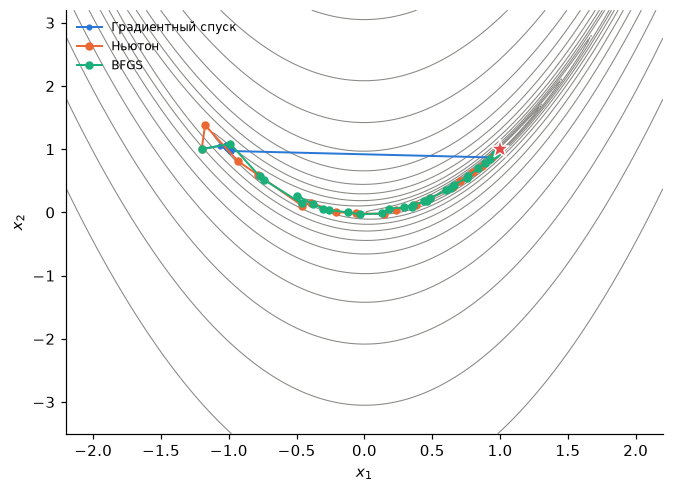

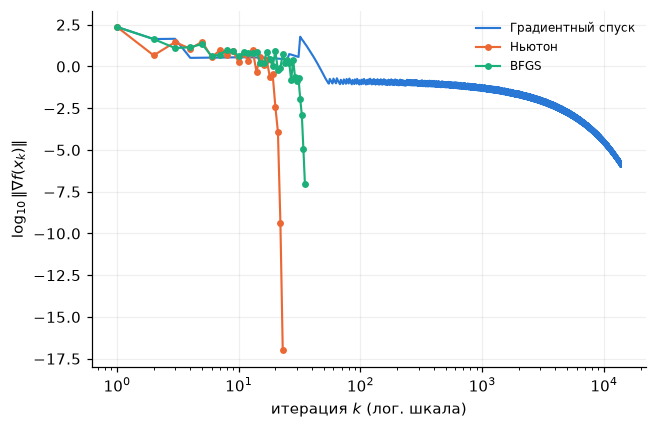

In [10]:
plot_rosen_path(
    [path_gd, path_newton, path_bfgs],
    labels=["Градиентный спуск", "Ньютон", "BFGS"]
)

plot_grad_norms(
    [gnorm_gd, gnorm_newton, gnorm_bfgs],
    labels=["Градиентный спуск", "Ньютон", "BFGS"]
)

**Ответ:** типы сходимостей по графику:
- Градиентный спуск - линейная сходимость: после начального участка норма градиента уменьшается постепенно, это соответствует приблизительно прямолинейному участку.
- Метод Ньютона - квадратичная сходимость вблизи минимума: на конце графика виден резкий обрыв: ошибка быстро уменьшается на много порядков за несколько итераций.
- BFGS - сверхлинейная сходимость: по мере приближения к минимуму сходимость ускоряется, и норма градиента резко падает.

In [11]:
energy, grad_E, H, b, v0 = make_chain(N=40)
L = np.linalg.eigvalsh(H).max()
alpha = 1.0 / L

v_gd, it_gd, path_gd, gnorm_gd = gd(
    energy, grad_E, v0, alpha=alpha
)
v_newton = v0 - np.linalg.solve(H, grad_E(v0))

print("Цепь N = 40")
print(f"L = {L:.6f}")
print(f"Шаг градиентного спуска = {alpha:.6e}")
print(f"Градиентный спуск: итераций = {it_gd}, энергия = {energy(v_gd):.10f}")
print(f"Ньютон: итераций = 1, энергия = {energy(v_newton):.10f}")
print(f"Расхождение решений = {np.linalg.norm(v_gd - v_newton):.6e}")


for N in [10, 20]:
    energy, grad_E, H, b, v0 = make_chain(N=N)
    v_bfgs, it_bfgs, path_bfgs, gnorm_bfgs = bfgs(
        energy, grad_E, v0, maxit=10_000
    )

    print(f"\nЦепь N = {N}")
    print(f"BFGS: итераций = {it_bfgs}")
    print(f"Энергия в конце = {energy(v_bfgs):.10f}")
    print(f"Норма градиента = {np.linalg.norm(grad_E(v_bfgs)):.6e}")

Цепь N = 40
L = 279.589212
Шаг градиентного спуска = 3.576676e-03
Градиентный спуск: итераций = 10575, энергия = 13.4417355854
Ньютон: итераций = 1, энергия = 13.4417355854
Расхождение решений = 2.431473e-06

Цепь N = 10
BFGS: итераций = 40
Энергия в конце = 78.0508383377
Норма градиента = 4.323014e-09

Цепь N = 20
BFGS: итераций = 10000
Энергия в конце = 44.7347246667
Норма градиента = 1.699489e-06


BFGS сошёлся для цепи $N = 10$: алгоритм остановился за 40 итераций при норме градиента $4.32 * 10^{-9}$. Для $N = 20$ сходимость не достигнута за отведённые 10 000 итераций, поскольку норма градиента $1.70 * 10^{-6}$ превышает критерий остановки $10^{-6}$. Проблема BFGS с одним лишь backtracking по Армихо в том, что условие Армихо контролирует только достаточное уменьшение функции, но не гарантирует хорошего шага для обновления приближения обратного гессиана: условие кривизны может нарушаться или выполняться слишком слабо, из-за чего обновления становятся неэффективными и сходимость замедляется. Это лечат, например, поиском шага Вольфе (условия Армихо и кривизны) или сильными условиями Вольфе, а также стратегиями регуляризации или сброса приближения обратного гессиана при неудачном обновлении.

### (в) Гаусс–Ньютон на синусе из ДЗ 2 (2 балла)

**TODO 4 — шаг Гаусса–Ньютона.** Допишите в `gauss_newton` строку с направлением: $p$ — решение линейного МНК $\min_p\lVert Jp+r\rVert^2$ (`np.linalg.lstsq`). Длина шага — ваш `armijo` на $f=\tfrac12\lVert r\rVert^2$ (демпфированный Гаусс–Ньютон). Проверка под ячейкой: на **линейных** невязках $r=Ax-b$ метод обязан сойтись за одну итерацию к `lstsq`.

Затем:

1. Запустите из $(1,\,3,\,0)$: ожидается $7$ итераций и $f^\ast=1.1393$, $x^\ast\approx(2.10,\,2.997,\,0.700)$. Сравните с вашим `bfgs` на `sine_f` из того же старта (итерации и вызовы функции) и со спуском ($731$ итерация в конспекте).
2. Запустите из всех 20 стартов `starts` ДЗ 2 (`maxit=200`). Сколько стартов пришли к глобальному $f^\ast=1.1393$ (с точностью $10^{-6}$)? Нарисуйте данные и все 20 подогнанных кривых одной картинкой. Объясните в двух предложениях, почему быстрый локальный метод не отменяет мультистарт из ДЗ 2.

Критерии: полный балл — проверка на линейных невязках проходит, числа пункта 1 воспроизведены, картинка и объяснение; половина — метод сходится, но без сравнения или без мультистарта.

In [12]:
def gauss_newton(resid, jac, x0, tol=1e-6, maxit=100):
    """Демпфированный Гаусс–Ньютон для f = 1/2 ||r||^2. Возвращает (x, итераций, путь, нормы градиента)."""
    f = lambda x: 0.5 * np.sum(resid(x) ** 2)
    x = np.asarray(x0, float).copy(); path = [x.copy()]; gnorm = []
    for k in range(maxit):
        r, J = resid(x), jac(x); g = J.T @ r; gnorm.append(np.linalg.norm(g))
        if gnorm[-1] <= tol:
            return x, k, np.array(path), np.array(gnorm)
        p = np.linalg.lstsq(J, -r, rcond=None)[0]
        x = x + armijo(f, x, p, g) * p; path.append(x.copy())
    return x, maxit, np.array(path), np.array(gnorm)

In [13]:
# проверка TODO 4: линейные невязки r = A x - b — один шаг из любого старта даёт решение lstsq
A_lin = rng.standard_normal((30, 4)); b_lin = rng.standard_normal(30)
x_lin, k_lin, _, _ = gauss_newton(lambda x: A_lin @ x - b_lin, lambda x: A_lin, np.ones(4), tol=1e-10)
assert k_lin == 1 and np.allclose(x_lin, np.linalg.lstsq(A_lin, b_lin, rcond=None)[0]), "на линейных невязках Гаусс–Ньютон должен совпасть с lstsq за одну итерацию: проверьте знак (-r) и что p решает именно min ||J p + r||"
print("TODO 4: ok")

TODO 4: ok


In [14]:
x_gn, it_gn, path_gn, gnorm_gn = gauss_newton(
    sine_resid, sine_jac, X0_SINE
)

f_bfgs, count_bfgs = count_f(sine_f)
x_bfgs, it_bfgs, path_bfgs, gnorm_bfgs = bfgs(
    f_bfgs, sine_grad, X0_SINE
)

f_gd, count_gd = count_f(sine_f)
x_gd, it_gd, path_gd, gnorm_gd = gd(
    f_gd, sine_grad, X0_SINE
)

print(f"{'Метод':<22} {'Итерации':>10} {'Вычисления f':>15} {'Конечная точка':>30}")
print("-" * 82)

for name, iterations, count, x in [
    ("Гаусс–Ньютон", it_gn, "—", x_gn),
    ("BFGS", it_bfgs, count_bfgs["n"], x_bfgs),
    ("Градиентный спуск", it_gd, count_gd["n"], x_gd),
]:
    print(f"{name:<22} {iterations:>10} {count:>15} {np.array2string(x, precision=6):>30}")

Метод                    Итерации    Вычисления f                 Конечная точка
----------------------------------------------------------------------------------
Гаусс–Ньютон                    7               —   [2.101393 2.996691 0.700264]
BFGS                           12              41   [2.101393 2.996691 0.700264]
Градиентный спуск             751            8970   [2.101393 2.996691 0.700264]


Стартов, пришедших к f* = 1.1393 с точностью 1e-4: 12 из 20
 Старт   Итерации          f(x*)                           Параметры
------------------------------------------------------------------------
     1          8     1.13927310           [-2.1014 -2.9967 -0.7003]
     2        128     1.13927310           [-2.1014 -2.9967 11.8661]
     3          9     1.13927310              [2.1014 2.9967 0.7003]
     4          7     1.13927310           [ 2.1014 -2.9967  2.4413]
     5          7     1.13927310              [2.1014 2.9967 0.7003]
     6         31    61.49727344           [ 0.4417  1.2981 -2.7238]
     7        103    61.68817068        [ -0.4532   5.8606 -31.9323]
     8         12     1.13927310           [ 2.1014 -2.9967 -3.8419]
     9          7     1.13927310           [-2.1014 -2.9967  5.5829]
    10         12     1.13927310           [-2.1014  2.9967 -8.7245]
    11         28    60.14144295        [  0.5765 -41.9039  41.1497]
    12         10     1.13927310       

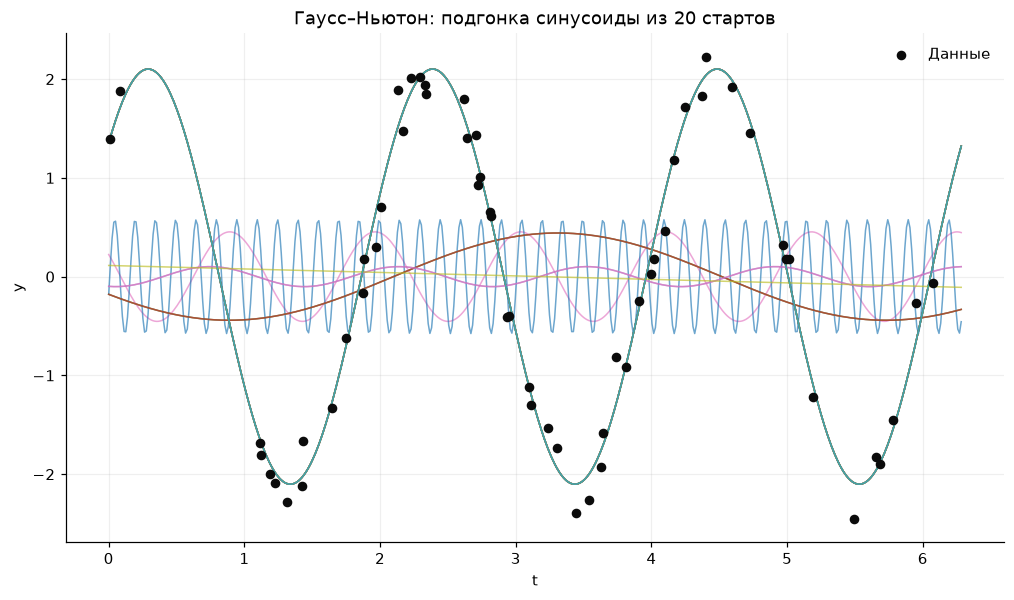

In [15]:
results = []

for i, x0 in enumerate(starts):
    x, it, path, gnorm = gauss_newton(
        sine_resid, sine_jac, x0, maxit=200
    )
    fval = sine_f(x)
    results.append({
        "start": i + 1,
        "x0": x0.copy(),
        "x": x,
        "iterations": it,
        "f": fval,
        "global_min": abs(fval - 1.1393) <= 1e-4
    })

n_global = sum(r["global_min"] for r in results)
print(f"Стартов, пришедших к f* = 1.1393 с точностью 1e-4: {n_global} из {len(starts)}")
print(f"{'Старт':>6} {'Итерации':>10} {'f(x*)':>14} {'Параметры':>35}")
print("-" * 72)

for r in results:
    print(f"{r['start']:>6} {r['iterations']:>10} {r['f']:>14.8f} {np.array2string(r['x'], precision=4):>35}")


t_plot = np.linspace(0, 2 * np.pi, 500)
plt.figure(figsize=(11, 6))
plt.scatter(t_data, y_data, label="Данные", color=INK, s=28, zorder=3)

for r in results:
    a, w, phi = r["x"]
    y_fit = a * np.sin(w * t_plot + phi)
    plt.plot(t_plot, y_fit, alpha=0.65, linewidth=1)

plt.xlabel("t")
plt.ylabel("y")
plt.title("Гаусс–Ньютон: подгонка синусоиды из 20 стартов")
plt.legend()
plt.show()

**Ответ:** 

Быстрый локальный метод находит минимум вблизи начальной точки, но из-за нелинейности функции может сойтись к локальному минимуму, а не к глобальному. Мультистарт позволяет запускать метод из разных начальных точек и повышает вероятность найти глобальный минимум.

## Бонус (+1 балл). L-BFGS своими руками

Реализуйте L-BFGS с памятью $m=5$: храните последние $m$ пар $(s_i,y_i)$ и вычисляйте $p=-H_kg$ двухпроходной рекурсией (*two-loop recursion*, Nocedal & Wright, алгоритм 7.4) с начальной матрицей $\gamma_kI$, $\gamma_k=s^\top y/y^\top y$ по последней паре; длина шага — ваш `armijo`. Запустите на цепи $N=40$ и сравните с `scipy.optimize.minimize(method="L-BFGS-B", options={"maxcor": 5})` по числу итераций (у SciPy — $75$) и с `np.linalg.solve` по времени; объясните, почему ваш вариант делает больше итераций (подсказка: §4.5 конспекта). Балл — за работающую рекурсию (проверка: на квадратичной $2\times2$ при $m\ge2$ после двух шагов направление совпадает с ньютоновским) и честное сравнение.

In [16]:
# ваш код


**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_